In [26]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
# dataset
data = pd.DataFrame({
    'Age': [22,25,47,52,46,56,23,27,30,40,35,48,50,29,31,42,37,45,33,26],
    'EstimatedSalary': [15000,20000,80000,90000,75000,100000,20000,30000,40000,60000,
                        65000,85000,95000,42000,52000,72000,68000,88000,48000,25000],
    'Purchased': [0,0,1,1,1,1,0,0,0,1,1,1,1,0,0,1,1,1,0,0]
})

X = data[['Age', 'EstimatedSalary']].values
y = data['Purchased'].values

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [30]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(X_train, y_train, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.5710
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8750 - loss: 0.5703
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8750 - loss: 0.5695
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8750 - loss: 0.5688
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.8750 - loss: 0.5680
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8750 - loss: 0.5673
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8750 - loss: 0.5665
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8750 - loss: 0.5658
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8750 - loss: 0.5651
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8750 - loss: 0.5643
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8750 - loss: 0.5636
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.875

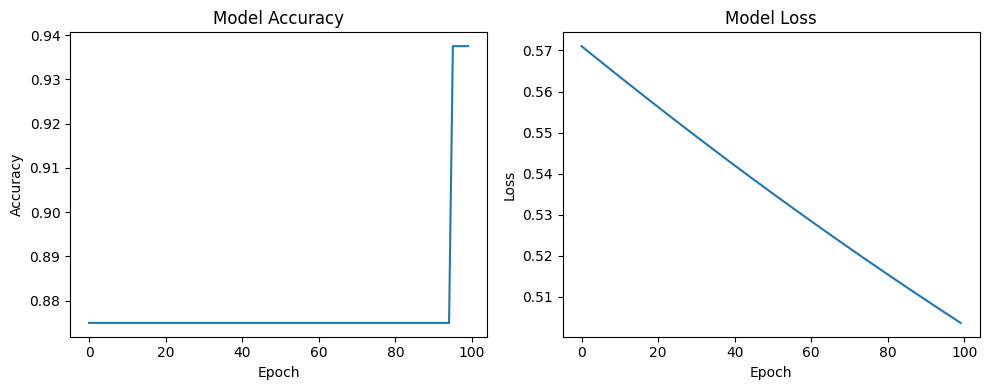

In [33]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [34]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - accuracy: 1.0000 - loss: 0.4779
Test Accuracy: 1.0


In [35]:
new_data = np.array([[30, 50000]])
new_data = sc.transform(new_data)

prediction = model.predict(new_data)
print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Prediction: [[0.41238302]]
